Simulation Complete. Final Battery Level: 37.61%
Total Local Executions: 42
Total Cloud Offloads: 8


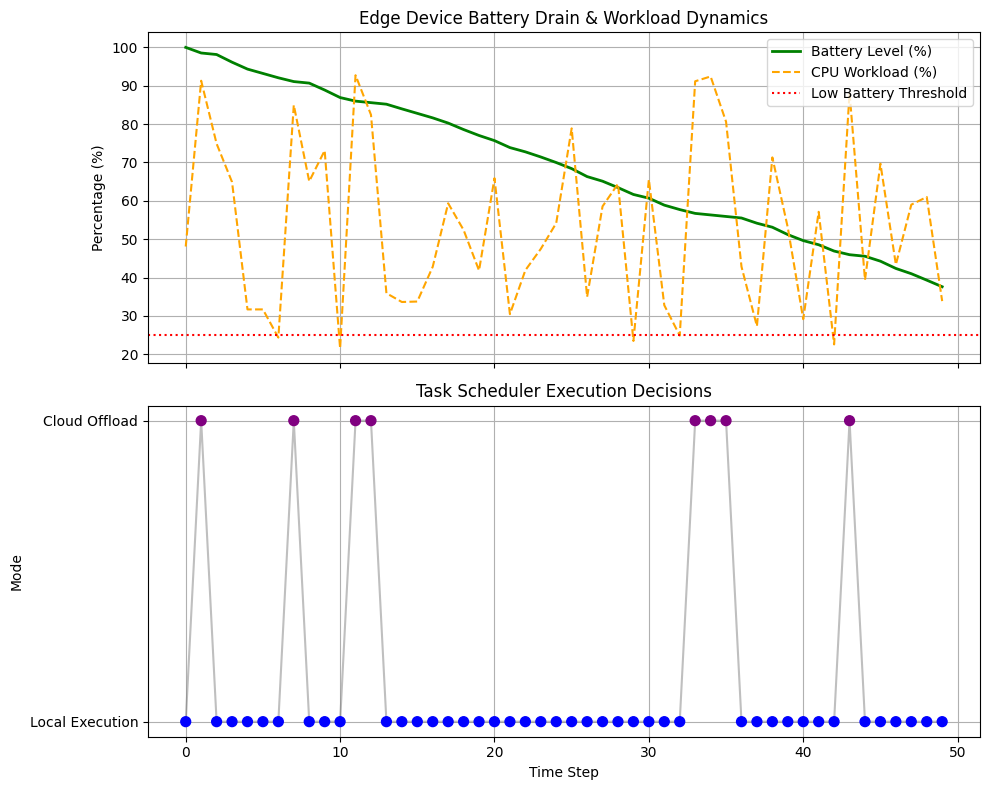

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def run_battery_scheduler_simulation():
    np.random.seed(42)

    # Simulation Parameters
    num_steps = 50
    battery = 100.0  # Initial battery percentage
    cpu_loads = np.random.uniform(20, 95, num_steps) # Synthetic CPU workload levels (%)

    decisions = []  # 0 for Local, 1 for Cloud
    battery_levels = [battery]

    # Thresholds for decision making
    BATTERY_LOW_THRESHOLD = 25.0
    CPU_HIGH_THRESHOLD = 80.0

    for t in range(num_steps):
        current_cpu = cpu_loads[t]

        # Decision Logic: Offload to cloud if battery is low OR CPU load is extremely high
        if battery < BATTERY_LOW_THRESHOLD or current_cpu > CPU_HIGH_THRESHOLD:
            decision = 1  # Cloud Offload
            # Cloud offloading consumes less local battery, but incurs a small communication cost
            battery_drain = 0.4
        else:
            decision = 0  # Local Execution
            # Local execution battery drain scales with CPU load
            battery_drain = 0.5 + (current_cpu / 50.0)

        decisions.append(decision)

        # Update battery level
        battery = max(0.0, battery - battery_drain)
        battery_levels.append(battery)

        # Stop simulation if battery dies
        if battery == 0.0:
            # Fill remaining steps if battery depleted
            decisions.extend([1] * (num_steps - len(decisions)))
            battery_levels.extend([0.0] * (num_steps - len(battery_levels)))
            break

    battery_levels = battery_levels[:num_steps]

    print(f"Simulation Complete. Final Battery Level: {battery_levels[-1]:.2f}%")
    print(f"Total Local Executions: {decisions.count(0)}")
    print(f"Total Cloud Offloads: {decisions.count(1)}")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Battery & Workload Plot
    ax1.plot(battery_levels, label='Battery Level (%)', color='green', linewidth=2)
    ax1.plot(cpu_loads[:len(battery_levels)], label='CPU Workload (%)', color='orange', linestyle='--', linewidth=1.5)
    ax1.axhline(BATTERY_LOW_THRESHOLD, color='red', linestyle=':', label='Low Battery Threshold')
    ax1.set_title('Edge Device Battery Drain & Workload Dynamics')
    ax1.set_ylabel('Percentage (%)')
    ax1.legend(loc='upper right')
    ax1.grid(True)

    # Decision Plot
    colors = ['blue' if d == 0 else 'purple' for d in decisions]
    ax2.scatter(range(len(decisions)), decisions, c=colors, s=50, zorder=3)
    ax2.plot(decisions, color='gray', linestyle='-', alpha=0.5, zorder=2)
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['Local Execution', 'Cloud Offload'])
    ax2.set_title('Task Scheduler Execution Decisions')
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Mode')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_battery_scheduler_simulation()